In [1]:
def plot_paths_and_histogram(time, paths, title):
    """
    Produces two side-by-side plots:
    Left  : Monte Carlo paths
    Right : Histogram of terminal returns
    """

    terminal_returns = paths[:, -1]# - paths[:, 0]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ---- Left: Paths ----
    for i in range(paths.shape[0]):
        axes[0].plot(time, paths[i], alpha=0.5)

    axes[0].set_xlabel("Time (Years)")
    axes[0].set_ylabel("Interest Rate")
    axes[0].set_title(f"{title} Paths")

    # ---- Right: Histogram ----
    axes[1].hist(terminal_returns, bins=30)
    axes[1].set_xlabel("Terminal Interest Rate")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title(f"{title} Terminal Interest Rate Distribution")

    plt.tight_layout()
    plt.show()

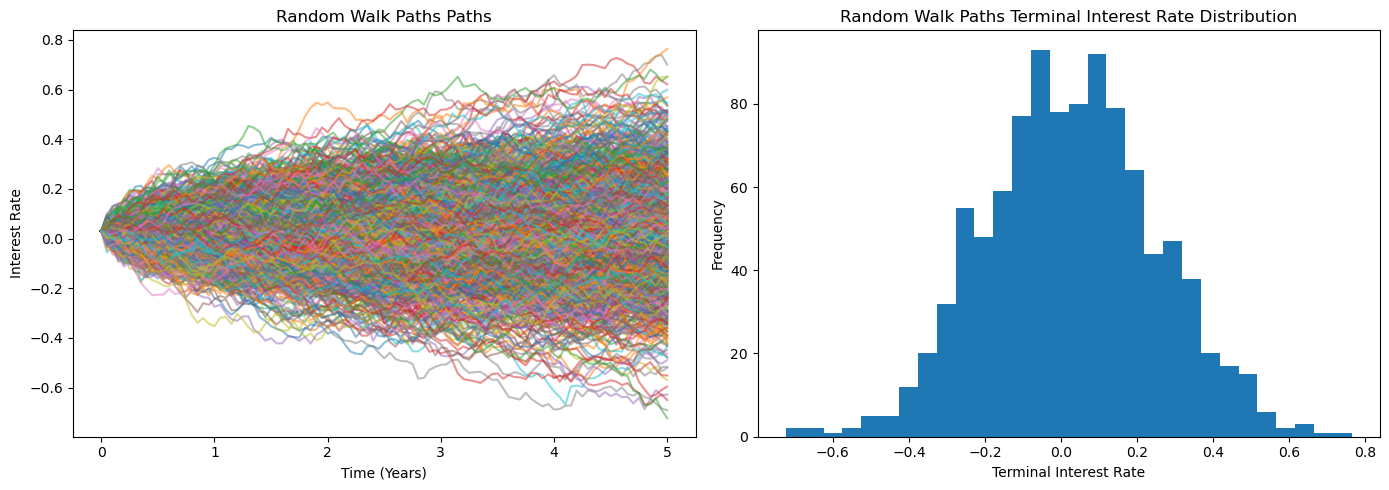

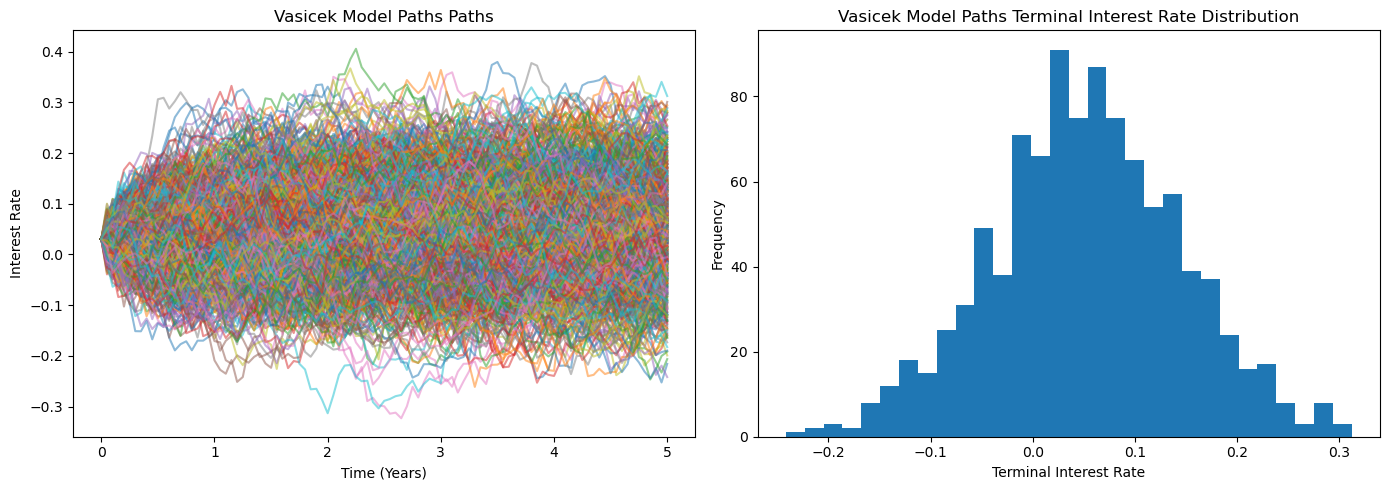

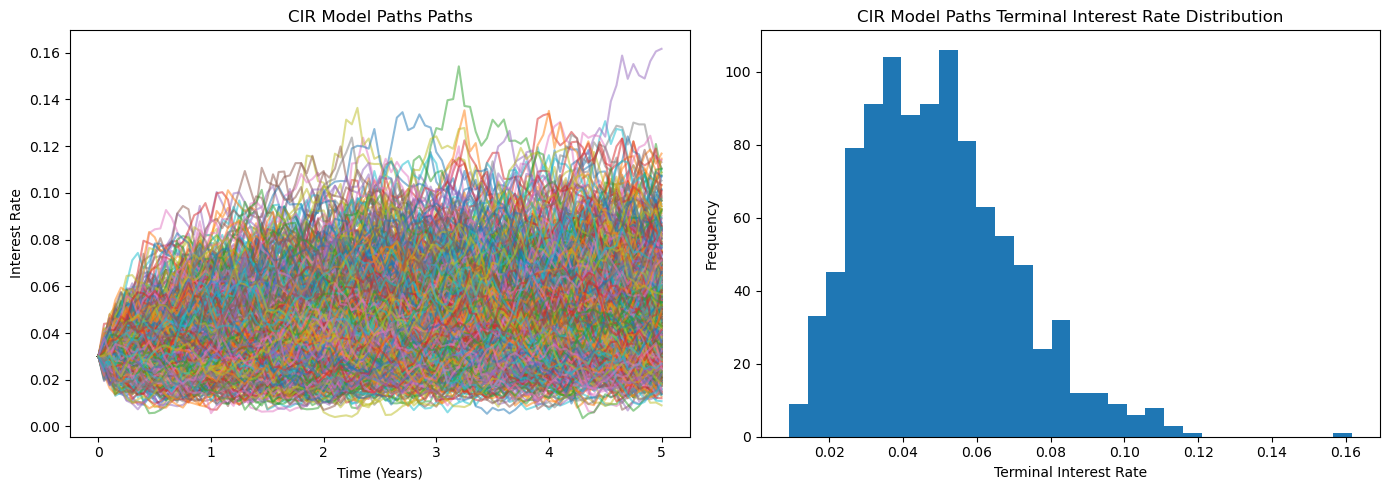

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================
# Random Walk Model
# dr = sigma dW
# =====================================================

def simulate_random_walk(r0, sigma, T, N, n_paths):
    dt = T / N
    time = np.linspace(0, T, N + 1)

    paths = np.zeros((n_paths, N + 1))
    paths[:, 0] = r0

    for i in range(N):
        z = np.random.normal(0, 1, n_paths)
        paths[:, i+1] = paths[:, i] + sigma * np.sqrt(dt) * z

    return time, paths


# =====================================================
# Vasicek Model
# dr = kappa(theta - r)dt + sigma dW
# =====================================================

def simulate_vasicek(kappa, theta, sigma, r0, T, N, n_paths):
    dt = T / N
    time = np.linspace(0, T, N + 1)

    rates = np.zeros((n_paths, N + 1))
    rates[:, 0] = r0

    for i in range(N):
        z = np.random.normal(0, 1, n_paths)
        rates[:, i+1] = (
            rates[:, i]
            + kappa * (theta - rates[:, i]) * dt
            + sigma * np.sqrt(dt) * z
        )

    return time, rates


# =====================================================
# CIR Model
# dr = kappa(theta - r)dt + sigma sqrt(r) dW
# =====================================================

def simulate_cir(kappa, theta, sigma, r0, T, N, n_paths):
    dt = T / N
    time = np.linspace(0, T, N + 1)

    rates = np.zeros((n_paths, N + 1))
    rates[:, 0] = r0

    for i in range(N):
        z = np.random.normal(0, 1, n_paths)
        rates[:, i+1] = (
            rates[:, i]
            + kappa * (theta - rates[:, i]) * dt
            + sigma * np.sqrt(np.maximum(rates[:, i], 0)) * np.sqrt(dt) * z
        )

        # Enforce non-negativity
        rates[:, i+1] = np.maximum(rates[:, i+1], 0)

    return time, rates


# =====================================================
# Parameters
# =====================================================

kappa = 0.6
theta = 0.05
sigma = 0.1
r0 = 0.03   # starting value - the worst possible outcome is -r0

T = 5.0
N = 100
n_paths = 1000


# =====================================================
# 1) Random Walk
# =====================================================

time_rw, rw_paths = simulate_random_walk(r0, sigma, T, N, n_paths)
plot_paths_and_histogram(time_rw, rw_paths, "Random Walk Paths")

# =====================================================
# 2) Vasicek
# =====================================================

time_vas, vas_paths = simulate_vasicek(kappa, theta, sigma, r0, T, N, n_paths)
plot_paths_and_histogram(time_vas, vas_paths, "Vasicek Model Paths")

# =====================================================
# 3) CIR
# =====================================================

time_cir, cir_paths = simulate_cir(kappa, theta, sigma, r0, T, N, n_paths)
plot_paths_and_histogram(time_cir, cir_paths, "CIR Model Paths")
